In [1]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os


In [86]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


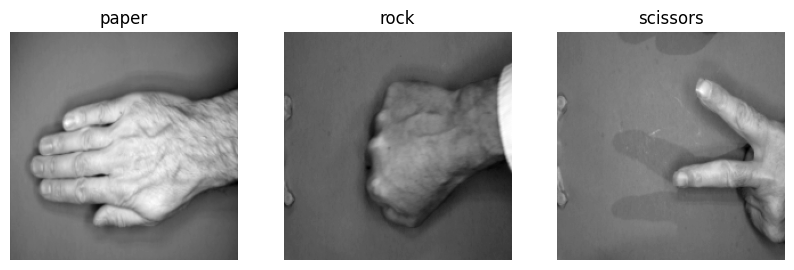

In [87]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [88]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
   
])

In [101]:
model_1 = keras.Sequential(
    [
    #data_augmentation,
    layers.Rescaling(1./255),
    layers.Resizing(96, 96),        
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3,activation='softmax')

    ]
)

In [102]:
model_1.summary()


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_26 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [103]:
model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [104]:
model_1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3344 - loss: 1.6897 - val_accuracy: 0.4656 - val_loss: 1.0039
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5506 - loss: 0.9768 - val_accuracy: 0.7656 - val_loss: 0.7937
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7448 - loss: 0.7364 - val_accuracy: 0.6750 - val_loss: 0.7276
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7620 - loss: 0.6404 - val_accuracy: 0.7781 - val_loss: 0.6275
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8438 - loss: 0.5010 - val_accuracy: 0.7844 - val_loss: 0.5644
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8655 - loss: 0.4217 - val_accuracy: 0.8531 - val_loss: 0.4404
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8847 - loss: 0.3688 - val_accuracy: 0.8938 - val_loss: 0.3912
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9207 - loss: 0.2945 - val_accuracy: 0.8625 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted label: paper
Actual label: paper


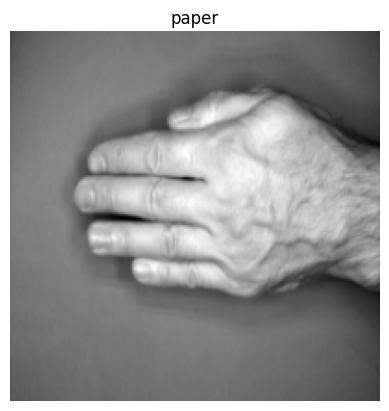

In [105]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [106]:
model_2 = keras.Sequential(
    [
        data_augmentation,
    layers.Rescaling(1./255),
   layers.Conv2D(16, (3, 3), activation="relu", input_shape=(128, 128, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(32, (3, 3), activation="relu"),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(84, activation="relu"),

    layers.Dense(3,activation='softmax')

    ]
)

In [107]:
model_2.summary()


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_24 (Sequential)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_27 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 198, 198, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_94 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,368,083 (16.66 MB)

 Trainable params: 4,368,083 (16.66 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [109]:
model_2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.3733 - loss: 1.1024 - val_accuracy: 0.7063 - val_loss: 0.8996
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5955 - loss: 0.8770 - val_accuracy: 0.8344 - val_loss: 0.5297
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7728 - loss: 0.6020 - val_accuracy: 0.8969 - val_loss: 0.3243
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8602 - loss: 0.3977 - val_accuracy: 0.9469 - val_loss: 0.1685
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8864 - loss: 0.3353 - val_accuracy: 0.9344 - val_loss: 0.2225
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9098 - loss: 0.2526 - val_accuracy: 0.9438 - val_loss: 0.2076
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9292 - loss: 0.2092 - val_accuracy: 0.9563 - val_loss: 0.1536
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9371 - loss: 0.1868 - val_accuracy: 0.9

In [170]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (7, 7), activation="relu", input_shape=(200, 200, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128, activation="relu",name='dense_1'),
    layers.Dropout(0.2),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [167]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (7, 7), input_shape=(128, 128, 1)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    layers.Dense(64),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [171]:
model_3.summary()


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_24 (Sequential)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_42 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_149 (Conv2D)             │ (None, 194, 194, 16)   │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_148               │ (None, 97, 97, 16)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_150 (Conv2D)             │ (None, 93, 93, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_149               │ (None, 46, 46, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_150               │ (None, 22, 22, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_151               │ (None, 10, 10, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_41 (Flatten)            │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,963 (6.69 MB)

 Trainable params: 1,752,963 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

In [172]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.3516 - loss: 1.0944 - val_accuracy: 0.7656 - val_loss: 0.8234
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.6564 - loss: 0.8394 - val_accuracy: 0.8062 - val_loss: 0.5047
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7691 - loss: 0.6023 - val_accuracy: 0.9156 - val_loss: 0.2722
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8868 - loss: 0.3539 - val_accuracy: 0.9438 - val_loss: 0.1905
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9168 - loss: 0.2765 - val_accuracy: 0.9594 - val_loss: 0.1552
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9363 - loss: 0.2190 - val_accuracy: 0.9750 - val_loss: 0.1179
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9332 - loss: 0.2154 - val_accuracy: 0.9688 - val_loss: 0.1123
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9356 - loss: 0.1832 - val_accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted label: scissors
Actual label: scissors


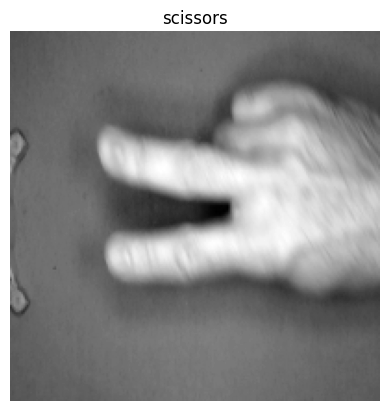

In [157]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h3>Leaky relu problem</h3>

<p>80% of the neurons are dead </p>

In [160]:
from tensorflow.keras.models import Model
import numpy as np

# Create a model that outputs activations of a specific layer
layer_output_model = Model(inputs=model_3.inputs,
                           outputs=model_3.get_layer("dense_1").output)

activations = layer_output_model.predict(image[None, ...])

# Count zeros
zero_fraction = np.mean(activations == 0)
print("Fraction of zero activations:", zero_fraction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Fraction of zero activations: 0.8046875
